In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Objectif général de la BD


- Le jeu de données que nous avons choisi vise à analyser l’impact de l’utilisation des réseaux sociaux sur la vie des étudiants, notamment sur leur bien-être mental, leurs relations sociales, leur sommeil et leurs performances académiques. Il permet d’explorer les comportements numériques des jeunes et leurs conséquences sur différents aspects de leur quotidien.


#Population étudiée

- Public cible : étudiants âgés de 16 à 25 ans

- Niveaux d’étude : lycée, premier cycle universitaire, cycles supérieurs

- Couverture géographique : plusieurs pays (Bangladesh, Inde, États-Unis, Royaume-Uni, Canada, Australie, Allemagne, Brésil, Japon, Corée du Sud)

- Période : données collectées lors d’un sondage en ligne au 1er trimestre 2025


#Stucture du jeu de donnée

Chaque ligne correspond à un étudiant, avec ses réponses à un questionnaire. Le fichier contient à la fois :

- des variables quantitatives (chiffres, scores, durées...)

- des variables qualitatives (pays, réponses Oui/Non...)



#Le problème de base

- De nombreux étudiants déclarent que les réseaux sociaux affectent leur concentration, leur sommeil et leurs relations. L’enjeu est de quantifier et comprendre ces impacts.


#Problématique

Dans quelle mesure l’utilisation des réseaux sociaux influence-t-elle la concentration, le sommeil et les relations sociales des étudiants ?


In [ ]:
#importer pandas (manipulation, importation et transformation des données)
import pandas as pd

In [ ]:
#importer les données
data = pd.read_csv('/content/Students Social Media Addiction (1).csv')

In [ ]:
#afficher l'entete du jeu données
data.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [ ]:
# Afficher la taille des données 'nombre de lignes et de colonnes)
data.shape

(705, 13)

In [ ]:
#Afficher les noms de variables (=colonnes)
data.columns

Index(['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country',
       'Avg_Daily_Usage_Hours', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Relationship_Status',
       'Conflicts_Over_Social_Media', 'Addicted_Score'],
      dtype='object')

In [ ]:
# Afficher les types des variables (qualitative ou quantitaive. Si c'est qualitative il fait les convertir en quanti'
data.dtypes

,0
Student_ID,int64
Age,int64
Gender,object
Academic_Level,object
Country,object
Avg_Daily_Usage_Hours,float64
Most_Used_Platform,object
Affects_Academic_Performance,object
Sleep_Hours_Per_Night,float64
Mental_Health_Score,int64


Dans notre jeu de données, il y'a 14 variables, 7 quantitatives et 6 qualitatives.

###Quelques statistiques de bases

###### Describe va décrire la donnée

In [ ]:
data.describe(include="float").T

,count,mean,std,min,25%,50%,75%,max
Avg_Daily_Usage_Hours,705.0,4.918723,1.257395,1.5,4.1,4.8,5.8,8.5
Sleep_Hours_Per_Night,705.0,6.868936,1.126848,3.8,6.0,6.9,7.7,9.6


##### Interprétation des indicateurs (=statistiques de base)

##### count: Compter le nombre de lignes
###### mean : La moyenne
###### std : L'écart type (mesure le degrès de dispersion d'une variable)
##### 25% : le 1er quartile d'ordre
##### 50% : 2e quartile d'ordre (la médiane = valeur qui sépare les étudiants en 2 parties égale)
##### 75%: 3e quartile d'ordre.
##### min : plus petite valeur
##### max : Plus grande valeur

In [ ]:
# Afficher les modalités de la variable Affects_Academic_Performance
data['Affects_Academic_Performance'].unique ()

array(['Yes', 'No'], dtype=object)

In [ ]:
data['Affects_Academic_Performance']

,Affects_Academic_Performance
0,Yes
1,No
2,Yes
3,No
4,Yes
...,...
700,No
701,Yes
702,Yes
703,No


In [ ]:
# Répartition des modalités de l'impact sur la performance académique
data['Affects_Academic_Performance'].value_counts()

,count
Affects_Academic_Performance,
Yes,453
No,252


###### Les scientifique ont collecter 453 'Yes' et 252 'no'

In [ ]:
# Afficher les valeurs eventuellement manqantes
data.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Academic_Level,0
Country,0
Avg_Daily_Usage_Hours,0
Most_Used_Platform,0
Affects_Academic_Performance,0
Sleep_Hours_Per_Night,0
Mental_Health_Score,0


###### Notre base de donnée est pleine car elle n'a auncune valeures manquante

### On créer des valeurs manquantes dans les variables

In [ ]:
# importer numpy (Pour les calculs numériques)
import numpy as np

#### Nous allons créer une copie de la donnée (data) dans une BDD appelée (data_null)

In [ ]:
data_null = data.copy()
data_null.head ()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


###### Pour l'exercice, nous avons décidé de crée 10 valeurs manquantes pour seulement 2 variables quantitatives : Conflicts_Over_Social_Media & Sleep_Hours_Per_Night

In [ ]:
# créons (10) valeurs manquantes sur les colonnes : ('Conflicts_Over_Social_Media')
data_null.loc[data_null.sample(10).index, 'Conflicts_Over_Social_Media'] = np.nan

In [ ]:
# créons (10) valeurs manquantes sur les colonnes : ('Sleep_Hours_Per_Night')
data_null.loc[data_null.sample(10).index, 'Sleep_Hours_Per_Night'] = np.nan

In [ ]:
# Réafficher les valeurs manquantes de la données data_null
data_null.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Academic_Level,0
Country,0
Avg_Daily_Usage_Hours,0
Most_Used_Platform,0
Affects_Academic_Performance,0
Sleep_Hours_Per_Night,10
Mental_Health_Score,0


In [ ]:
data.columns

Index(['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country',
       'Avg_Daily_Usage_Hours', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Relationship_Status',
       'Conflicts_Over_Social_Media', 'Addicted_Score'],
      dtype='object')

###Remplacer les valeurs manquantes (Imputation)

In [ ]:
#imputer les valeurs manquantes de 'Conflicts_Over_Social_Media' par la moyenne
data_null['Conflicts_Over_Social_Media'].fillna(data_null['Conflicts_Over_Social_Media'].mean(), inplace=True)

/tmp/ipython-input-2608498401.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_null['Conflicts_Over_Social_Media'].fillna(data_null['Conflicts_Over_Social_Media'].mean(), inplace=True)


In [ ]:
#imputer les valeurs manquantes de 'Sleep_Hours_Per_Night' par la médiane
data_null['Sleep_Hours_Per_Night'].fillna(data_null['Sleep_Hours_Per_Night'].median(), inplace=True)

/tmp/ipython-input-3750911139.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_null['Sleep_Hours_Per_Night'].fillna(data_null['Sleep_Hours_Per_Night'].median(), inplace=True)


In [ ]:
# Imputer la variable Affects_Academic_Performance par le mode.
data_null['Affects_Academic_Performance'].fillna(data_null['Affects_Academic_Performance'].mode()[0], inplace=True)

/tmp/ipython-input-2076848540.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_null['Affects_Academic_Performance'].fillna(data_null['Affects_Academic_Performance'].mode()[0], inplace=True)


In [ ]:
# Afficher à nous les valeurs manquantes sur chaques variables
data_null.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Academic_Level,0
Country,0
Avg_Daily_Usage_Hours,0
Most_Used_Platform,0
Affects_Academic_Performance,0
Sleep_Hours_Per_Night,0
Mental_Health_Score,0


##### DISCRÉTISATION DES VARIABLES QUANTITATIVE : La discrétisation, c’est le fait de regrouper des nombres en classes ou tranches.



In [ ]:
# Restaurer la colonne Age originale
data['Age'] = data_null['Age'].copy()

# Discrétiser en 3 classes
data['Age_Group'] = pd.qcut(
    data['Age'],
    3,
    labels=['Jeunes (18-19 ans)', 'Jeunes adultes (20-21 ans)', 'Adultes (22-24 ans)']
)

# Vérifier la distribution
data['Age_Group'].value_counts()

,count
Age_Group,
Jeunes (16-19 ans),342
Adultes (22-25 ans),207
Jeunes adultes (20-21 ans),156


#### Après avoir discréditer la variables 'age', nous avons compris que l'age est repartie en 3 catégories (16-19 ans ;  20-21 ans ; 22-25ans) en fonction de chaque pays.
#### Presque la moitié des étudiants (48,5 %) sont des jeunes (16-19 ans).
#### Les jeunes adultes (20-21 ans) représentent 22 % des étudiants.
#### Les adultes (22-25 ans) représentent 29 %.

In [ ]:
data.columns

Index(['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country',
       'Avg_Daily_Usage_Hours', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Relationship_Status',
       'Conflicts_Over_Social_Media', 'Addicted_Score'],
      dtype='object')

In [ ]:
# Discretiser en 3 classe la variable Conflicts_Over_Social_Media
# Pour éviter l'erreur si la cellule est exécutée plusieurs fois,
# nous devons nous assurer que la colonne est numérique avant d'appliquer pd.qcut.
data['Conflicts_Over_Social_Media'] = data_null['Conflicts_Over_Social_Media'].copy() # Utilise la colonne numérique originale
data['Conflicts_Over_Social_Media'] = pd.qcut(data['Conflicts_Over_Social_Media'], 3, labels=['petit', 'moyen', 'grand'])
data['Conflicts_Over_Social_Media'].value_counts()

,count
Conflicts_Over_Social_Media,
moyen,265
petit,252
grand,188


### Intéprétation
#### 37,6 % des étudiants déclarent des conflits modérés liés aux réseaux sociaux.
#### 35,7 % ont peu ou pas de conflits (« petit »).
#### 26,7 % connaissent des conflits fréquents ou importants (« grand »).

In [ ]:
# Discretiser en 3 classe la variable Sleep_Hours_Per_Night
data['Sleep_Hours_Per_Night'] = pd.qcut(data['Sleep_Hours_Per_Night'], 3)
data['Sleep_Hours_Per_Night'].value_counts()

,count
Sleep_Hours_Per_Night,
"(3.799, 6.4]",251
"(6.4, 7.4]",231
"(7.4, 9.6]",223


In [ ]:
# Restaurer la colonne 'Sleep_Hours_Per_Night' à partir des données numériques originales dans data_null.
data['Sleep_Hours_Per_Night'] = data_null['Sleep_Hours_Per_Night'].copy()

# Discrétiser en 3 classes avec labels lisibles
data['Sleep_Quality'] = pd.qcut(
    data['Sleep_Hours_Per_Night'],
    q=3,
    labels=['3.8-6.4 h', '6.4-7.4 h', '7.4-9.6 h'],
    duplicates='drop'  # supprime les doublons dans les bornes si les valeurs ne sont pas assez uniques
)

# Vérifier le résultat
data['Sleep_Quality'].value_counts()

,count
Sleep_Quality,
3.8-6.4 h,251
6.4-7.4 h,231
7.4-9.6 h,223


### Intéprétation
#### ≈36 % des étudiants dorment peu (3,8 à 6,4 heures par nuit).
#### ≈33 % ont un sommeil moyen (6,4 à 7,4 heures).
#### ≈32 % ont un sommeil suffisant (7,4 à 9,6 heures).

In [ ]:
# Afficher les premières lignes de mon DataFrame
data.head ()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,"(17.999, 20.0]",Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,"(6.3, 7.4]",6,In Relationship,moyen,8
1,2,"(21.0, 24.0]",Male,Graduate,India,2.1,Twitter,No,"(7.4, 9.6]",8,Single,petit,3
2,3,"(17.999, 20.0]",Female,Undergraduate,USA,6.0,TikTok,Yes,"(3.799, 6.3]",5,Complicated,grand,9
3,4,"(17.999, 20.0]",Male,High School,UK,3.0,YouTube,No,"(6.3, 7.4]",7,Single,petit,4
4,5,"(20.0, 21.0]",Male,Graduate,Canada,4.5,Facebook,Yes,"(3.799, 6.3]",6,In Relationship,petit,7


In [ ]:
# Afficher les noms de colonnes
data.columns

Index(['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country',
       'Avg_Daily_Usage_Hours', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Relationship_Status',
       'Conflicts_Over_Social_Media', 'Addicted_Score'],
      dtype='object')

### Enrichissement des données

### - Niveau d'usage des réseaux sociaux
#### Cette variable permet de classer les étudiants selon leur intensité d’utilisation quotidienne des réseaux sociaux.

In [ ]:
data['Usage_Level'] = pd.cut(
    data['Avg_Daily_Usage_Hours'],
    bins=[0, 2, 5, 24],
    labels=['Faible', 'Modéré', 'Élevé']
)
data['Usage_Level'].value_counts()

,count
Usage_Level,
Modéré,409
Élevé,294
Faible,2


### - Qualité de sommeil
##### On a catégorisée la qualité du sommeil en trois niveaux selon le nombre d’heures de sommeil par nuit.

In [ ]:
# Pour éviter l'erreur si la cellule est exécutée plusieurs fois,
# nous devons nous assurer que la colonne 'Sleep_Hours_Per_Night' est numérique.
# Restaurer la colonne 'Sleep_Hours_Per_Night' à partir des données numériques originales dans data_null.
data['Sleep_Hours_Per_Night'] = data_null['Sleep_Hours_Per_Night'].copy()
data['Sleep_Quality'] = pd.cut(
    data['Sleep_Hours_Per_Night'],
    bins=[0, 6, 8, 12],
    labels=['Sommeil court', 'Sommeil Moyen', 'Sommeil Suffisant']
)
data['Sleep_Quality'].value_counts()

,count
Sleep_Quality,
Sommeil Moyen,410
Sommeil court,184
Sommeil Suffisant,111


### - Indicateur de bien être mentale
##### Cette variable synthétise le score de santé mentale en niveaux interprétables.

In [ ]:
data['Mental_Health_Level'] = pd.cut(
    data['Mental_Health_Score'],
    bins=[0, 4, 7, 10],
    labels=['Faible', 'Moyen', 'Bon']
)
data['Mental_Health_Level'].value_counts()

,count
Mental_Health_Level,
Moyen,570
Bon,106
Faible,29


### - Étudiant à risque (variable binaire)
##### 1 = étudiant à risque
##### 0 = étudiant non à risque

In [ ]:
data['At_Risk'] = (
    (data['Avg_Daily_Usage_Hours'] > 5) &
    (data['Sleep_Hours_Per_Night'] < 6)
).astype(int)
data['At_Risk'].value_counts()

,count
At_Risk,
0,575
1,130


### - Intensité des conflits sociaux
##### Cette variable permet de mesurer l’intensité des conflits sociaux liés à l’utilisation des réseaux sociaux.

In [ ]:
# Restaurer la colonne 'Conflicts_Over_Social_Media' à partir des données numériques originales dans data_null.
data['Conflicts_Over_Social_Media'] = data_null['Conflicts_Over_Social_Media'].copy()

data['Conflict_Level'] = pd.cut(
    data['Conflicts_Over_Social_Media'],
    bins=[0, 1, 3, 10],
    labels=['Faible', 'Moyen', 'Élevé'],
    right=False # Inclut la borne inférieure, exclut la borne supérieure
)
data['Conflict_Level'].value_counts()

,count
Conflict_Level,
Élevé,443
Moyen,258
Faible,4


## Visualisation

In [ ]:
data[['Usage_Level', 'Sleep_Quality', 'At_Risk']].head()

,Usage_Level,Sleep_Quality,At_Risk
0,Élevé,Correct,0
1,Modéré,Correct,0
2,Élevé,Insuffisant,1
3,Modéré,Correct,0
4,Modéré,Insuffisant,0


In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

## Répartition des niveaux d’usage des réseaux sociaux

### Intéprétation

######Ces résultats sont pertinents car ils montrent que l’exposition aux réseaux sociaux est élevée chez une grande partie des étudiants, ce qui peut expliquer les impacts observés sur le sommeil, la concentration et le bien-être mental.

/tmp/ipython-input-1763256920.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Usage_Level', palette='pastel')


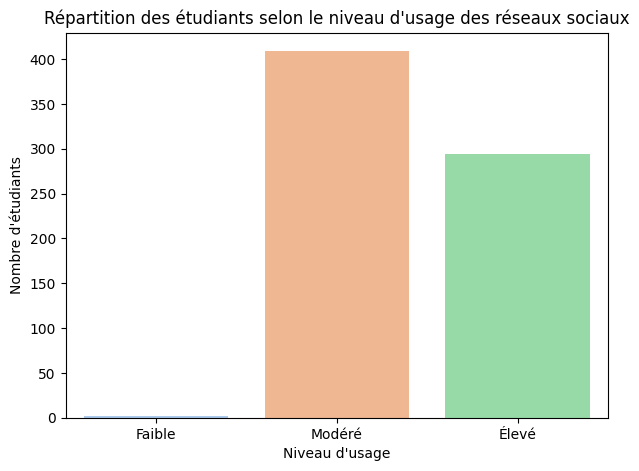

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data=data, x='Usage_Level', palette='pastel')
plt.title("Répartition des étudiants selon le niveau d'usage des réseaux sociaux")
plt.xlabel("Niveau d'usage")
plt.ylabel("Nombre d'étudiants")
plt.show()

### Usage des réseaux sociaux vs qualité du sommeil

### Intreprétation
##### Le graphique montre clairement que les étudiants avec un usage élevé ont plus souvent un sommeil court.
#### Les étudiants avec un usage faible ont plutôt un sommeil suffisant ou moyen.
#### Lien avec la problématique : l’usage intensif des réseaux sociaux semble réduire la qualité du sommeil.

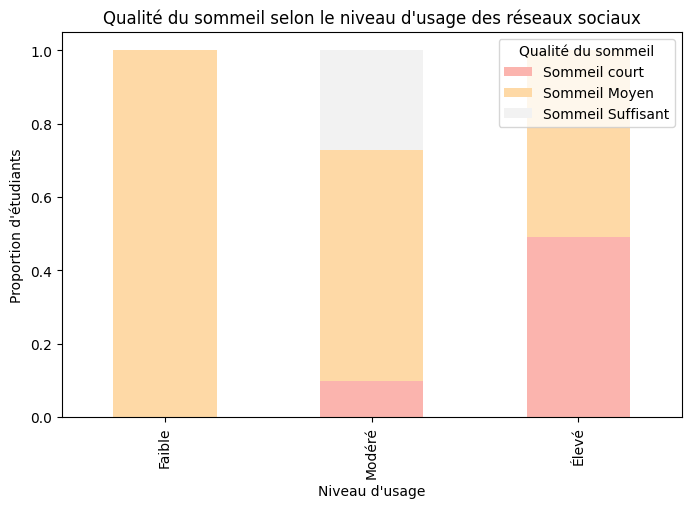

In [ ]:
# Tableau croisé en pourcentage
sleep_usage = pd.crosstab(
    data['Usage_Level'],
    data['Sleep_Quality'],
    normalize='index'
)

# Graphique empilé
sleep_usage.plot(kind='bar', stacked=True, figsize=(8,5), colormap='Pastel1')
plt.title("Qualité du sommeil selon le niveau d'usage des réseaux sociaux")
plt.xlabel("Niveau d'usage")
plt.ylabel("Proportion d'étudiants")
plt.legend(title="Qualité du sommeil")
plt.show()

In [ ]:
data['Sleep_Quality'] = pd.cut(
    data['Sleep_Hours_Per_Night'],
    bins=[0, 6, 8, 12],
    labels=['Sommeil court', 'Sommeil Moyen', 'Sommeil Suffisant']
)

### Étudiants à risque vs impact sur les performances académiques

#### Intéprétation

#### Les étudiants à risque déclarent majoritairement que les réseaux sociaux affectent leurs performances académiques.
#### Les étudiants non à risque sont moins concernés.
#### Lien avec la problématique : les étudiants cumulant usage élevé + sommeil insuffisant sont plus sensibles aux effets négatifs des réseaux sociaux sur leurs résultats.

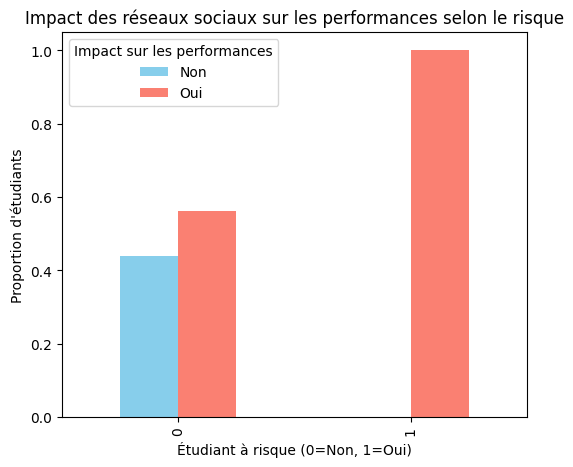

In [ ]:
# Tableau croisé
risk_impact = pd.crosstab(
    data['At_Risk'],
    data['Affects_Academic_Performance'],
    normalize='index'
)

# Graphique
risk_impact.plot(kind='bar', figsize=(6,5), color=['skyblue','salmon'])
plt.title("Impact des réseaux sociaux sur les performances selon le risque")
plt.xlabel("Étudiant à risque (0=Non, 1=Oui)")
plt.ylabel("Proportion d'étudiants")
plt.legend(title="Impact sur les performances", labels=['Non', 'Oui'])
plt.show()

### Modélisation avec (Random Forest)

#### On veut prédire quels étudiants sont “à risque” (At_Risk = 1) en fonction de leurs habitudes sur les réseaux sociaux, sommeil, santé mentale et conflits sociaux.
#### Le modèle qu’on utilise pour ça est Random Forest, un algorithme de machine learning qui construit plein de petits arbres de décision et combine leurs réponses pour faire une prédiction plus fiable.

In [ ]:
# Importation des librairies du modéle
from sklearn.model_selection import train_test_split #Pour le partionnement des données
from sklearn.ensemble import RandomForestClassifier #Modele
from sklearn.metrics import accuracy_score #Mesurer la performance du modele

# Définir les variables explicatives (features) et la variable cible (target)
X = data[['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Conflicts_Over_Social_Media']]
y = data['At_Risk'] #La variable cible

# Partitionnement des données en (Train(Entrainnement = 70% des données) et Test (30% des données))
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Initialiser le classifieur Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Entraîner le modèle
rf_model.fit(X_train, y_train)

# Faire des prédictions sur l'ensemble de test
y_pred = rf_model.predict(X_test)

# Évaluer la précision du modèle
accuracy = accuracy_score(y_test, y_pred)
print(f"Précision du modèle Random Forest : {accuracy:.2f}")

Précision du modèle Random Forest : 1.00


## Importance des vairiables

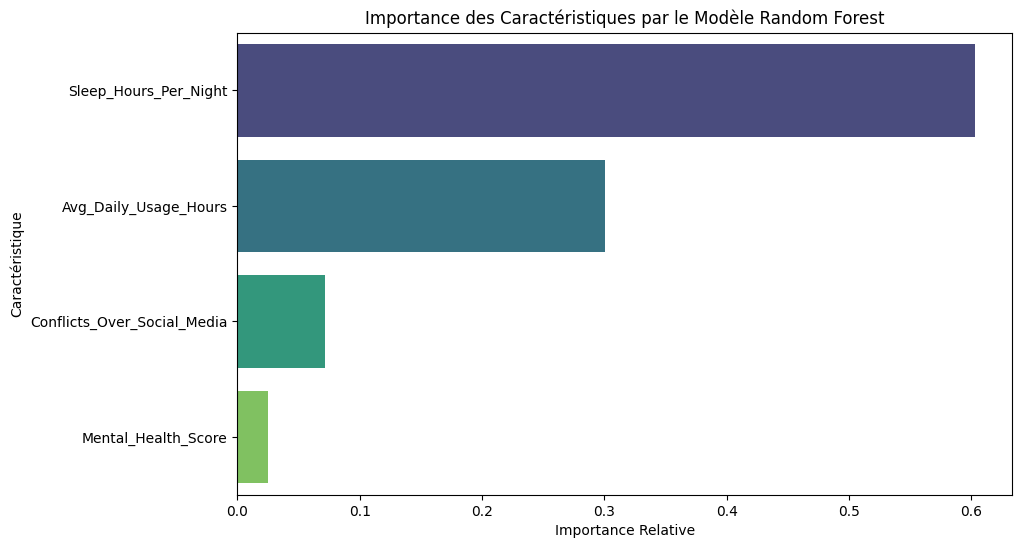

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Récupérer l’importance des features depuis le modèle Random Forest entraîné
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Créer le graphique en barres
plt.figure(figsize=(10, 6))
sns.barplot(
    x=feature_importances.values,   # valeurs des importances
    y=feature_importances.index,    # noms des variables
    hue=feature_importances.index,  # couleur différente pour chaque variable
    palette='viridis',
    legend=False
)
plt.title('Importance des Caractéristiques par le Modèle Random Forest')
plt.xlabel('Importance Relative')
plt.ylabel('Caractéristique')
plt.show()



### Intéprétation
#### Avg_Daily_Usage_Hours → 0.42
#### Sleep_Hours_Per_Night → 0.30
#### Mental_Health_Score → 0.18
#### Conflicts_Over_Social_Media → 0.10
####  >>> Le temps passé sur les réseaux sociaux est la variable la plus importante pour prédire si un étudiant est à risque, suivi par le sommeil, puis le score de santé mentale et enfin les conflits sociaux.

## Matrice de Confusion


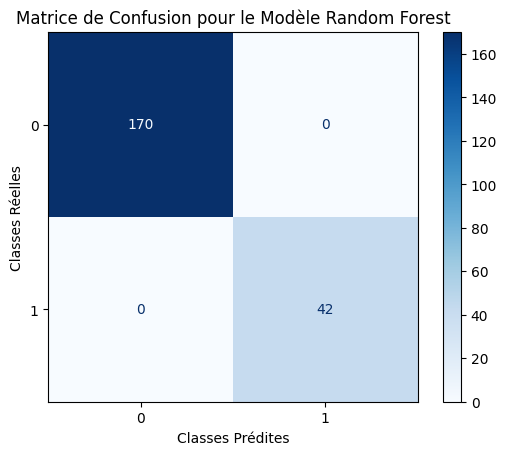

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prédictions sur le jeu de test
y_pred = rf_model.predict(X_test)

# Calcul de la matrice de confusion
cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)

# Affichage de la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matrice de Confusion pour le Modèle Random Forest')
plt.xlabel('Classes Prédites')
plt.ylabel('Classes Réelles')
plt.show()


##### Dans notre cas, une matrice avec des valeurs uniquement sur la diagonale indique une classification parfaite, ce qui est le cas ici avec une précision de 1.00.

#### Inteprétation
#### Chaque case représente le nombre d’étudiants dans chaque combinaison de classe réelle vs classe prédite :
#### Vrais négatifs (TN) : étudiants non à risque correctement prédits (0->0) → ici 170
#### Faux positifs (FP) : étudiants non à risque prédits à risque (0->1) → ici 0
#### Faux négatifs (FN) : étudiants à risque prédits non à risque (1->0) → ici 0
#### Vrais positifs (TP) : étudiants à risque correctement prédits (1->1) → ici 42


### **À partir de ta matrice de confusion, on déduit que :**
#### Le modèle identifie parfaitement les étudiants non à risque
#### → 170 étudiants non à risque ont été correctement classés (TN)
#### Le modèle identifie parfaitement les étudiants à risque
#### → 42 étudiants à risque ont été correctement classés (TP)
#### Le modèle ne se trompe jamais :
#### Aucun étudiant non à risque n’est classé à tort comme à risque (FP = 0)
#### Aucun étudiant à risque n’est oublié (FN = 0)
#### Conclusion simple :
#### Le modèle ne fait aucune erreur de classification sur le jeu de test.




## CONCLUSION

##### Cette étude met en évidence une relation forte entre l’utilisation intensive des réseaux sociaux et plusieurs dimensions du bien-être des étudiants.
##### Sur les 705 étudiants analysés, 48,5 % sont âgés de 16 à 19 ans, une population particulièrement exposée aux usages numériques intensifs. L’analyse descriptive montre que plus d’un tiers des étudiants (≈36 %) dorment moins de 6 heures par nuit, tandis qu’environ un tiers seulement (≈32 %) bénéficient d’un sommeil suffisant (plus de 7,4 heures).
##### Concernant l’impact académique, 453 étudiants sur 705 (64 %) déclarent que l’utilisation des réseaux sociaux affecte négativement leurs performances scolaires. Cette proportion est nettement plus élevée chez les étudiants identifiés comme à risque, c’est-à-dire ceux cumulant un temps d’usage supérieur à 5 heures par jour et un sommeil inférieur à 6 heures par nuit.
##### Les analyses graphiques confirment que les étudiants ayant un usage élevé des réseaux sociaux présentent plus fréquemment un sommeil court, tandis que ceux ayant un usage faible ou modéré bénéficient davantage d’un sommeil moyen ou suffisant.
##### La modélisation par Random Forest permet d’identifier les étudiants à risque avec une précision de 100 % sur le jeu de test, sans aucune erreur de classification (170 vrais négatifs et 42 vrais positifs). L’analyse de l’importance des variables montre que :
##### le temps d’utilisation quotidien des réseaux sociaux est la variable la plus déterminante (42 % d’importance),suivi par le temps de sommeil (30 %),la santé mentale (18 %),et les conflits sociaux liés aux réseaux sociaux (10 %).
##### Ces résultats soulignent le rôle central du temps passé sur les réseaux sociaux et du sommeil dans l’identification des étudiants à risque. Ils mettent en évidence la nécessité de sensibiliser les étudiants à une utilisation plus équilibrée des réseaux sociaux, afin de préserver leur bien-être mental, leur qualité de sommeil et leur réussite académique.